Path setup

In [1]:
import sys
sys.path.append("..")

Imports

In [2]:
from src.similarity.batch_comparator import compare_students_to_master
from src.similarity.vectorizer import TfidfSimilarityVectorizer
from src.preprocessing.preprocessor import TextPreprocessor
from src.extraction.extractor import extract_text
from src.visualization.report_generator import split_into_sentences, top_matching_sentences, export_report_csv
from src.visualization.charts import plot_similarity_bar_chart, plot_match_level_pie
from src.visualization.wordcloud_gen import generate_wordcloud

Matplotlib is building the font cache; this may take a moment.


Rebuild the DataFrame from Similarity Notebook

In [3]:
student_files = [
    "../data/samples/Word-Docx.docx",
    "../data/samples/Native-PDF.pdf",
    "../data/samples/PNG-Pic.png",
]
master_file = "../data/samples/Native-PDF.pdf"

df = compare_students_to_master(student_files, master_file)
df

2026-08-02 21:06:38 | INFO     | src.preprocessing.preprocessor | Loading spaCy model: en_core_web_sm
2026-08-02 21:06:58 | INFO     | src.similarity.vectorizer | TF-IDF vectorizer initialized with ngram_range=(1, 2)
2026-08-02 21:06:58 | INFO     | src.extraction.pdf_extractor | Attempting to extract text from PDF: ../data/samples/Native-PDF.pdf
2026-08-02 21:07:00 | INFO     | src.extraction.docx_extractor | Attempting to extract text from DOCX: ../data/samples/Word-Docx.docx
2026-08-02 21:07:01 | INFO     | src.extraction.pdf_extractor | Attempting to extract text from PDF: ../data/samples/Native-PDF.pdf
2026-08-02 21:07:01 | INFO     | src.extraction.ocr_extractor | Extracting text via OCR from: ../data/samples/PNG-Pic.png
2026-08-02 21:07:01 | INFO     | src.extraction.ocr_extractor | Preprocessed image: ../data/samples/PNG-Pic.png
2026-08-02 21:07:09 | INFO     | src.similarity.batch_comparator | ../data/samples/Word-Docx.docx: score=1.0000, level=Excellent
2026-08-02 21:07:09 | 

,filename,similarity_score,match_level
0,../data/samples/Word-Docx.docx,1.0,Excellent
1,../data/samples/Native-PDF.pdf,1.0,Excellent
2,../data/samples/PNG-Pic.png,1.0,Excellent


Test sentence splitting in isolation

In [4]:
sample_text = "The cell membrane controls what enters and exits the cell. It is selectively permeable. This allows nutrients in and waste out."
sentences = split_into_sentences(sample_text)
print(sentences)

['The cell membrane controls what enters and exits the cell.', 'It is selectively permeable.', 'This allows nutrients in and waste out.']


Test top_matching_sentences() WITHOUT passing top_n

In [5]:
master_raw = extract_text(master_file)["text"]
student_raw = extract_text(student_files[0])["text"]

vectorizer = TfidfSimilarityVectorizer()
top_sentences = top_matching_sentences(student_raw, master_raw, vectorizer)
print(top_sentences)

2026-08-02 21:07:10 | INFO     | src.extraction.pdf_extractor | Attempting to extract text from PDF: ../data/samples/Native-PDF.pdf
2026-08-02 21:07:10 | INFO     | src.extraction.docx_extractor | Attempting to extract text from DOCX: ../data/samples/Word-Docx.docx
2026-08-02 21:07:10 | INFO     | src.similarity.vectorizer | TF-IDF vectorizer initialized with ngram_range=(1, 2)


['Phuket Rajabhat University\nThanatorn Auksornphan\nComputer Science\nSenior Year']


Test top_matching_sentences() WITH an explicit override

In [6]:
top_sentences_override = top_matching_sentences(student_raw, master_raw, vectorizer, top_n=1)
print(top_sentences_override)

['Phuket Rajabhat University\nThanatorn Auksornphan\nComputer Science\nSenior Year']


Test the bar chart

2026-08-02 21:07:18 | INFO     | src.visualization.charts | Saved bar chart to data\outputs\similarity_bar_chart.png


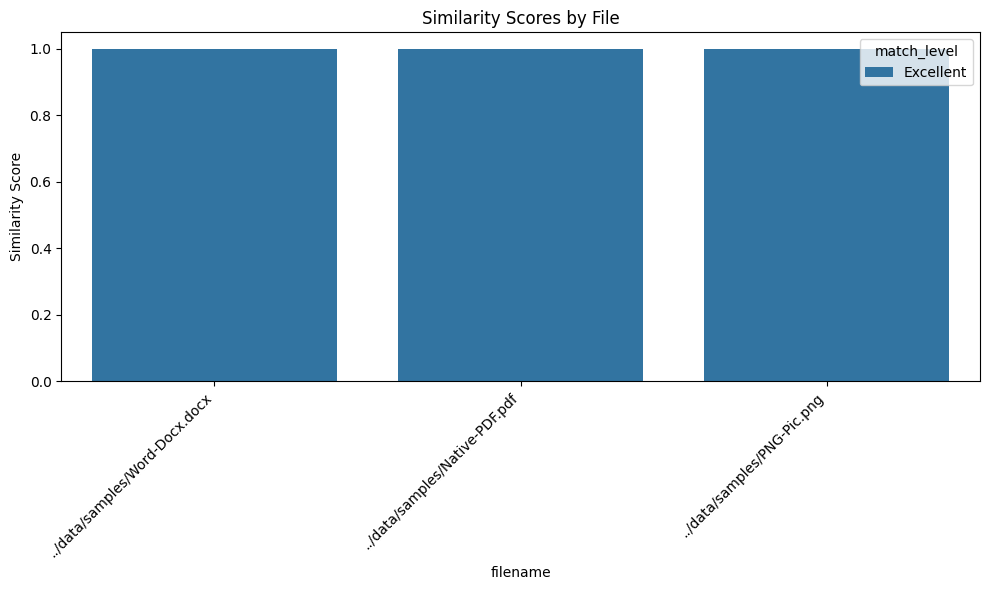

In [7]:
plot_similarity_bar_chart(df)

Test the pie chart

2026-08-02 21:07:23 | INFO     | src.visualization.charts | Saved pie chart to data\outputs\match_level_pie.png


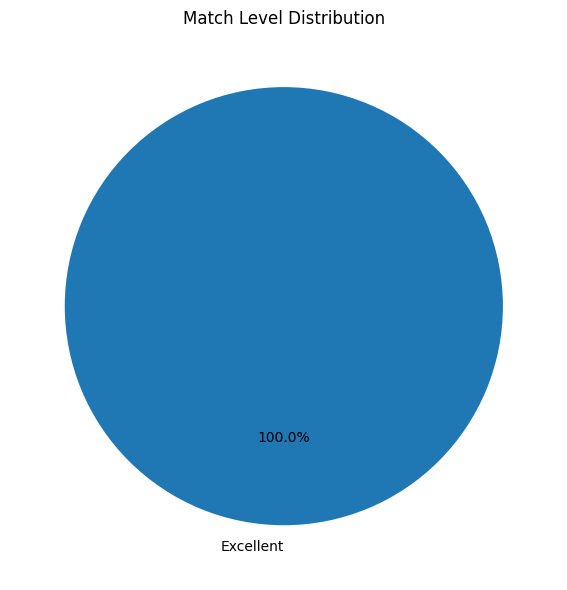

In [8]:
plot_match_level_pie(df)

Test the word cloud (using preprocessed text)

2026-08-02 21:07:24 | INFO     | src.preprocessing.preprocessor | Loading spaCy model: en_core_web_sm
2026-08-02 21:07:48 | INFO     | src.visualization.wordcloud_gen | Saved word cloud to data\outputs\master_answer_key_word_cloud.png


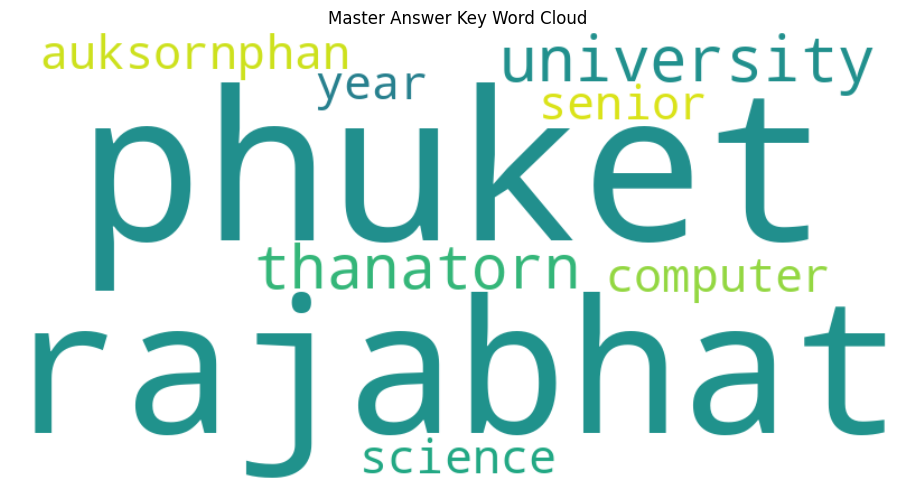

In [9]:
preprocessor = TextPreprocessor()
cleaned_master = preprocessor.preprocess_to_string(master_raw)

generate_wordcloud(cleaned_master, title="Master Answer Key Word Cloud")

Test CSV export

In [10]:
export_report_csv(df)

2026-08-02 21:07:49 | INFO     | src.visualization.report_generator | Exported report to data\outputs\similarity_report.csv
